<a href="https://colab.research.google.com/github/nishthha01/nishthha01/blob/main/disease_prediction_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#Upload and Unzip
from google.colab import files
import zipfile, os

uploaded = files.upload()

# Extract uploaded ZIP
zip_path = next(iter(uploaded))
extract_path = '/content/disease_data'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Check contents
print("Extracted files:", os.listdir(extract_path))

Saving disease_prediction_ML.zip to disease_prediction_ML.zip
Extracted files: ['Testing.csv', 'Training.csv']


In [5]:
# Load data from extracted path
train_path = os.path.join(extract_path, 'Training.csv')
test_path = os.path.join(extract_path, 'Testing.csv')

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print("Training shape:", df_train.shape)
print("Testing shape:", df_test.shape)
df_train.head()

Training shape: (4920, 134)
Testing shape: (42, 133)


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [6]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize, LabelBinarizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_curve, auc, confusion_matrix
from sklearn.multiclass import OneVsRestClassifier

In [7]:
# remove unnamed columns
df_train = df_train.loc[:, ~df_train.columns.str.contains('^Unnamed')]
df_test = df_test.loc[:, ~df_test.columns.str.contains('^Unnamed')]

In [8]:
# Encodeing target labels
le = LabelEncoder()
df_train['prognosis'] = le.fit_transform(df_train['prognosis'])
df_test['prognosis'] = le.transform(df_test['prognosis'])

In [9]:
# Split feature and Labels
X_train = df_train.drop('prognosis', axis=1)
y_train = df_train['prognosis']
X_test = df_test.drop('prognosis', axis=1)
y_test = df_test['prognosis']

In [10]:
# Missing values
imputer = SimpleImputer(strategy='constant', fill_value=0)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [11]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
# Hyperparameter tuning (Random Forest)
rf_params = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]}
rf_grid = GridSearchCV(RandomForestClassifier(), rf_params, cv=3, scoring='f1_macro')
rf_grid.fit(X_train, y_train)
print("\nBest Random Forest Params:", rf_grid.best_params_)
best_rf = rf_grid.best_estimator_


Best Random Forest Params: {'max_depth': None, 'n_estimators': 100}


In [14]:
# Cross-validation for best RF model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring='accuracy')
print("\n Cross-Validation Accuracy Scores:", cv_scores)
print(" Mean CV Accuracy:", np.mean(cv_scores))


 Cross-Validation Accuracy Scores: [1. 1. 1. 1. 1.]
 Mean CV Accuracy: 1.0


In [15]:
# Defining models
models = {
    "Random Forest (Tuned)": best_rf,
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(probability=True)
}


In [16]:
# Training and evaluatation
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')
    recall = recall_score(y_test, preds, average='macro')

    results[name] = {"Accuracy": acc, "F1 Score": f1, "Recall": recall}

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("Recall:", recall)


Random Forest (Tuned)
Accuracy: 0.9761904761904762
F1 Score: 0.9837398373983739
Recall: 0.9878048780487805

Logistic Regression
Accuracy: 0.9761904761904762
F1 Score: 0.9837398373983739
Recall: 0.9878048780487805

Decision Tree
Accuracy: 0.9761904761904762
F1 Score: 0.9837398373983739
Recall: 0.9878048780487805

SVM
Accuracy: 0.9761904761904762
F1 Score: 0.9837398373983739
Recall: 0.9878048780487805


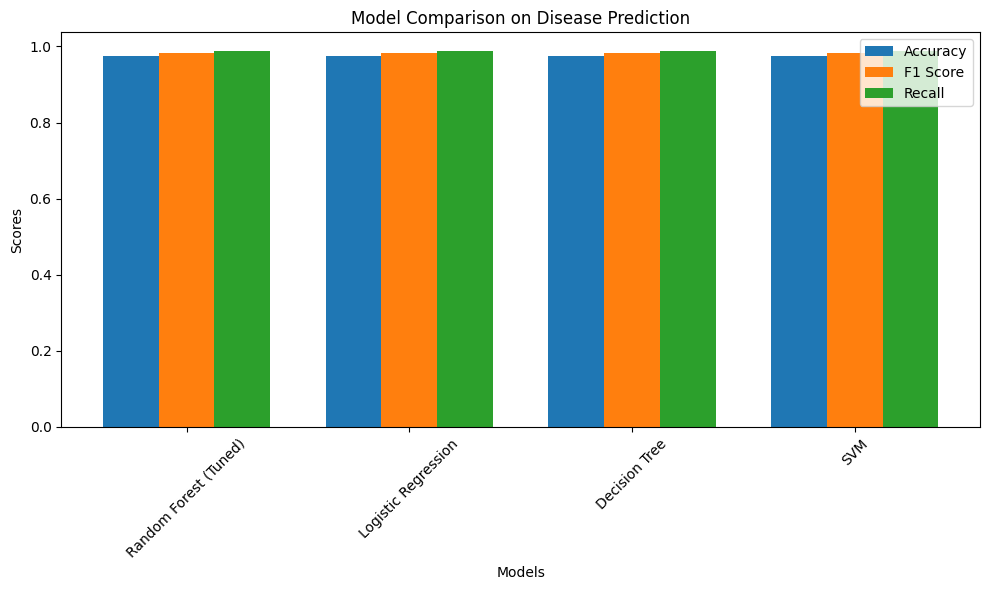

In [18]:
# Plot model performance
labels = list(results.keys())
acc_values = [results[model]['Accuracy'] for model in labels]
f1_values = [results[model]['F1 Score'] for model in labels]
recall_values = [results[model]['Recall'] for model in labels]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, acc_values, width, label='Accuracy')
plt.bar(x, f1_values, width, label='F1 Score')
plt.bar(x + width, recall_values, width, label='Recall')

plt.xlabel("Models")
plt.ylabel("Scores")
plt.title("Model Comparison on Disease Prediction")
plt.xticks(x, labels, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


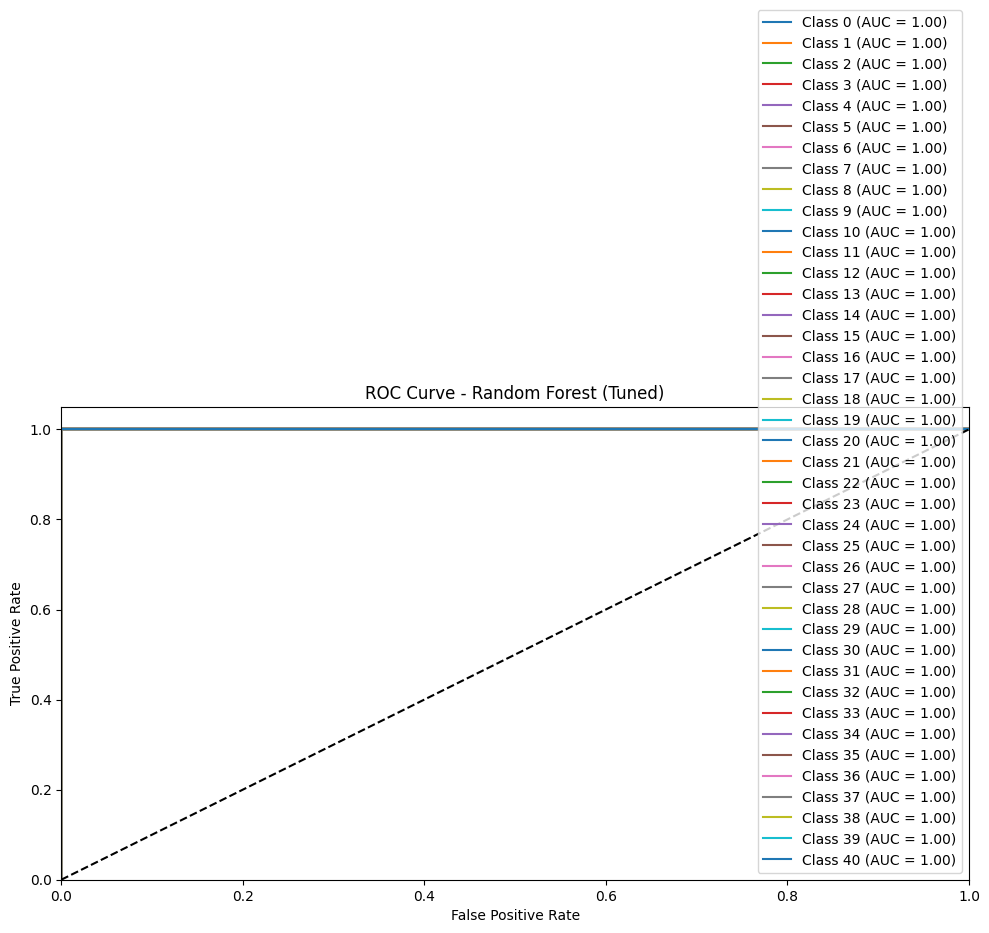

In [19]:
# ROC Curve for best RF model (multiclass)
# One-vs-rest strategy for multiclass ROC
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
y_score = best_rf.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(lb.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(len(lb.classes_)):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (Tuned)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

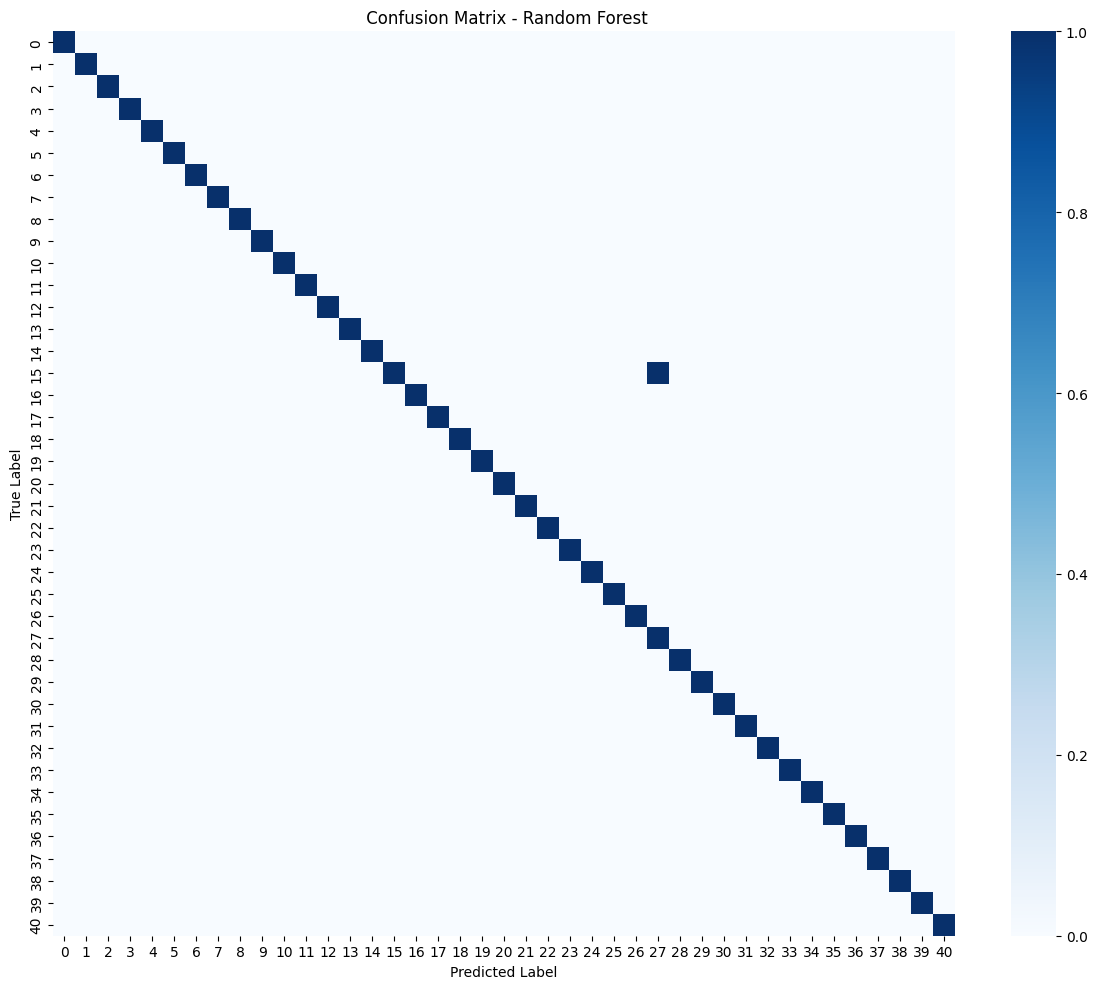

In [20]:
# Confusion Matrix for Random Forest
rf_preds = best_rf.predict(X_test)
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.title(' Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


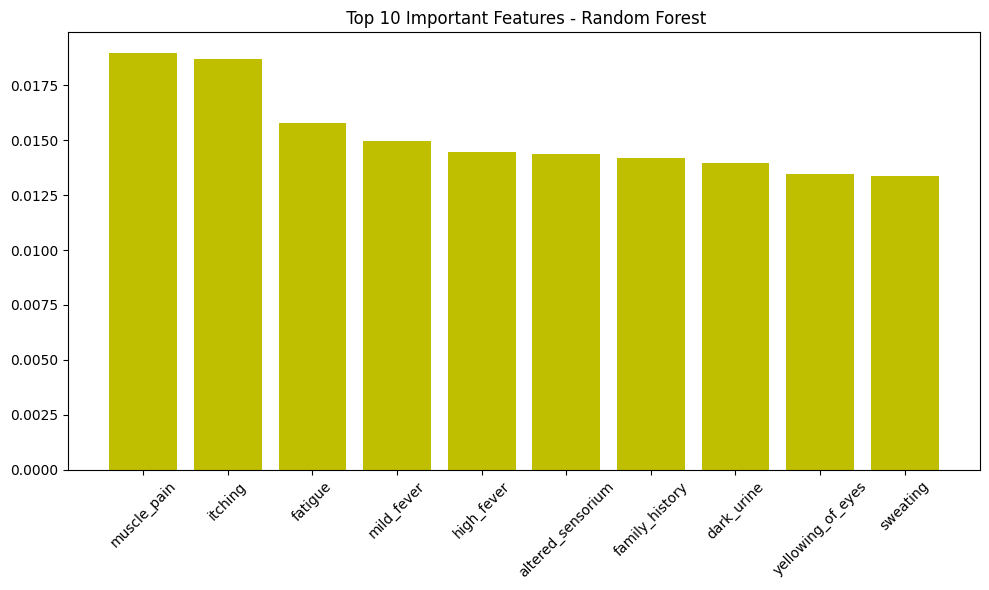

In [21]:
# Feature Importance Plot (Random Forest)
importances = best_rf.feature_importances_
indices = np.argsort(importances)[-10:][::-1]  # Top 10 features
feature_names = df_train.drop('prognosis', axis=1).columns

plt.figure(figsize=(10, 6))
plt.title(" Top 10 Important Features - Random Forest")
plt.bar(range(len(indices)), importances[indices], color="y", align="center")
plt.xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()